# Analise dos resultados - Trabalho 4 (Link Extractor)

Este notebook consolida os CSVs gerados pelo Locust em `results/raw/`,
produz a planilha `results/processed/consolidado.xlsx` e gera **10 graficos**
comparativos em `results/charts/`.

**Pre-requisito**: ter rodado `scripts/run-all-scenarios.ps1` (ou cenarios
individuais) para popular `results/raw/` com os 12 cenarios.

**Como executar**: abra no VSCode (extensao Jupyter) ou via terminal:
```powershell
.\\.venv\\Scripts\\jupyter.exe lab analysis/analise.ipynb
```
Clique em **Run All** para gerar a planilha e todos os graficos de uma vez.

## 1. Imports e caminhos

Configura as dependencias e define os caminhos para `raw/`, `processed/` e `charts/`.

In [46]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
RAW = ROOT / "results" / "raw"
PROCESSED = ROOT / "results" / "processed"
CHARTS = ROOT / "results" / "charts"
PROCESSED.mkdir(parents=True, exist_ok=True)
CHARTS.mkdir(parents=True, exist_ok=True)

print(f"ROOT      = {ROOT}")
print(f"RAW       = {RAW}")
print(f"PROCESSED = {PROCESSED}")
print(f"CHARTS    = {CHARTS}")
print(f"\nCSVs encontrados em raw: {len(list(RAW.glob('*_stats.csv')))}")

ROOT      = c:\Users\kaike\Desktop\nabor\linkextractor-loadtest
RAW       = c:\Users\kaike\Desktop\nabor\linkextractor-loadtest\results\raw
PROCESSED = c:\Users\kaike\Desktop\nabor\linkextractor-loadtest\results\processed
CHARTS    = c:\Users\kaike\Desktop\nabor\linkextractor-loadtest\results\charts

CSVs encontrados em raw: 12


## 2. Consolidacao dos CSVs do Locust

Cada cenario gera 4 arquivos com prefixo `<versao>_<cache>_<usuarios>u_<duracao>`.
Extrai a linha `Aggregated` de cada `*_stats.csv` (metricas finais)
e junta todos os `*_stats_history.csv` (serie temporal) em um DataFrame consolidado.

In [47]:
NAME_RE = re.compile(
    r"^(?P<version>python|ruby)_(?P<cache>warm|cold)_(?P<users>\d+)u_(?P<runtime>[^_]+)_stats\.csv$"
)

def parse_tag(filename: str):
    m = NAME_RE.match(filename)
    if not m:
        return None
    return {
        "version": m.group("version"),
        "cache": m.group("cache"),
        "users": int(m.group("users")),
        "runtime": m.group("runtime"),
    }

rows = []
for csv in sorted(RAW.glob("*_stats.csv")):
    tag = parse_tag(csv.name)
    if tag is None:
        continue
    df = pd.read_csv(csv)
    agg = df[df["Name"] == "Aggregated"]
    if agg.empty:
        agg = df.tail(1)
    r = agg.iloc[0].to_dict()
    rows.append({
        **tag,
        "requests": int(r.get("Request Count", 0)),
        "failures": int(r.get("Failure Count", 0)),
        "rps": r.get("Requests/s", float("nan")),
        "mean_ms": r.get("Average Response Time", float("nan")),
        "median_ms": r.get("Median Response Time", float("nan")),
        "p95_ms": r.get("95%", float("nan")),
        "p99_ms": r.get("99%", float("nan")),
        "min_ms": r.get("Min Response Time", float("nan")),
        "max_ms": r.get("Max Response Time", float("nan")),
    })

if not rows:
    raise RuntimeError("Nenhum *_stats.csv em results/raw/. Rode os cenários antes.")

resumo = pd.DataFrame(rows).sort_values(["version", "cache", "users"]).reset_index(drop=True)
resumo

,version,cache,users,runtime,requests,failures,rps,mean_ms,median_ms,p95_ms,p99_ms,min_ms,max_ms
0,python,cold,10,2m,2188,0,18.416152,432.026704,380,840,1100,68.7634,1758.7952
1,python,cold,50,2m,4082,234,34.399475,1327.236424,1200,2900,3600,2.3347,4565.3137
2,python,cold,100,2m,3967,6,33.458120,2808.855444,2500,5000,6900,21.5650,8565.6710
3,python,warm,10,2m,10820,0,91.031876,8.612432,6,13,21,3.4219,1011.1815
4,python,warm,50,2m,36785,10216,309.334537,58.771935,45,110,200,2.2547,2974.7343
5,python,warm,100,2m,44902,20,378.054090,158.409409,110,240,830,19.2937,7779.0805
6,ruby,cold,10,2m,2189,189,18.419820,437.345731,410,860,1000,28.1254,3718.1868
7,ruby,cold,50,2m,5575,1157,46.977920,948.075312,890,1800,2300,54.5988,5196.4593
8,ruby,cold,100,2m,5617,1175,47.269661,1961.861149,1700,4400,6300,79.0145,10092.8280
9,ruby,warm,10,2m,11110,0,93.593727,5.079103,3,7,10,1.8673,743.8736


In [48]:
frames = []
for csv in sorted(RAW.glob("*_stats_history.csv")):
    base = csv.name.replace("_stats_history.csv", "_stats.csv")
    tag = parse_tag(base)
    if tag is None:
        continue
    df = pd.read_csv(csv)
    for k, v in tag.items():
        df[k] = v
    frames.append(df)

series = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
print(f"Linhas na série temporal consolidada: {len(series)}")
series.head()

Linhas na série temporal consolidada: 1392


,Timestamp,User Count,Type,Name,Requests/s,Failures/s,50%,66%,75%,80%,...,Total Failure Count,Total Median Response Time,Total Average Response Time,Total Min Response Time,Total Max Response Time,Total Average Content Size,version,cache,users,runtime
0,1778465568,0,NaN,Aggregated,0.0,0.0,NaN,NaN,NaN,NaN,...,0,0.0,0.000000,0.0000,0.0000,0.000000,python,cold,100,2m
1,1778465569,20,NaN,Aggregated,0.0,0.0,800.0,810.0,820.0,820.0,...,0,790.0,780.442920,689.6409,829.3404,84.000000,python,cold,100,2m
2,1778465570,40,NaN,Aggregated,0.0,0.0,720.0,790.0,810.0,820.0,...,0,700.0,699.861976,475.4438,979.6001,1320.086957,python,cold,100,2m
3,1778465571,60,NaN,Aggregated,0.0,0.0,830.0,1200.0,1200.0,1200.0,...,0,830.0,930.020053,331.9882,1587.1720,5709.829545,python,cold,100,2m
4,1778465572,100,NaN,Aggregated,20.0,0.0,830.0,1200.0,1200.0,1200.0,...,0,830.0,943.090851,331.9882,1716.9729,5629.072165,python,cold,100,2m


## 3. Planilha consolidada

Salva `results/processed/consolidado.xlsx` com duas abas:
- **resumo** - uma linha por cenario com media, mediana, p95, p99, RPS e falhas
- **series** - serie temporal completa de todos os cenarios

In [49]:
out_path = PROCESSED / "consolidado.xlsx"
with pd.ExcelWriter(out_path, engine="openpyxl") as w:
    resumo.to_excel(w, sheet_name="resumo", index=False)
    if not series.empty:
        series.to_excel(w, sheet_name="series", index=False)

print(f"Salvo: {out_path}")

Salvo: c:\Users\kaike\Desktop\nabor\linkextractor-loadtest\results\processed\consolidado.xlsx


## 4. Graficos

Todos os graficos usam barras agrupadas para facilitar a comparacao visual
entre as quatro combinacoes de versao e cache.

Os graficos **4.1 a 4.5** mostram as principais metricas por nivel de carga (10/50/100 usuarios).
Os graficos **4.6 a 4.10** trazem analises complementares:
falhas absolutas, comparacao direta com/sem cache, speedup do cache,
taxa de erros percentual e heatmap de latencia.

Todos os PNGs sao salvos automaticamente em `results/charts/`.

In [50]:
import numpy as np

_CACHE_LABEL = {"warm": "com cache", "cold": "sem cache"}

def _fmt(v):
    """Formata numero: inteiro abreviado se >= 1000."""
    if v >= 1000: return f"{v/1000:.1f}k"
    if v >= 10:   return f"{v:.0f}"
    return f"{v:.1f}"

def bar_by_users(df, metric, ylabel, title, fname):
    combos  = [(v, c) for v in df["version"].unique() for c in ["warm", "cold"]]
    groups  = sorted(df["users"].unique())
    palette = {"python/warm": "steelblue", "python/cold": "lightskyblue",
               "ruby/warm":   "seagreen",  "ruby/cold":   "lightgreen"}
    n, x, w = len(combos), np.arange(len(groups)), 0.18

    fig, ax = plt.subplots(figsize=(9, 5))
    for i, (version, cache) in enumerate(combos):
        vals = [
            df.loc[(df["version"]==version)&(df["cache"]==cache)&(df["users"]==u),
                   metric].values[0]
            for u in groups
        ]
        offset = (i - n/2 + 0.5) * w
        bars = ax.bar(x + offset, vals, w,
                      label=f"{version} / {_CACHE_LABEL[cache]}",
                      color=palette.get(f"{version}/{cache}"))
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() * 1.01,
                    _fmt(val),
                    ha="center", va="bottom", fontsize=6.5)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{u}u" for u in groups])
    ax.set_xlabel("Usuarios virtuais")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)
    ax.legend()
    fig.tight_layout()
    out = CHARTS / fname
    fig.savefig(out, dpi=120)
    plt.show()
    print(f"  salvo: {out}")

### 4.1. Tempo medio de resposta

Compara o tempo medio (ms) das quatro combinacoes versao/cache por nivel de carga.
Indica o comportamento central do sistema - valores altos sinalizam degradacao geral.

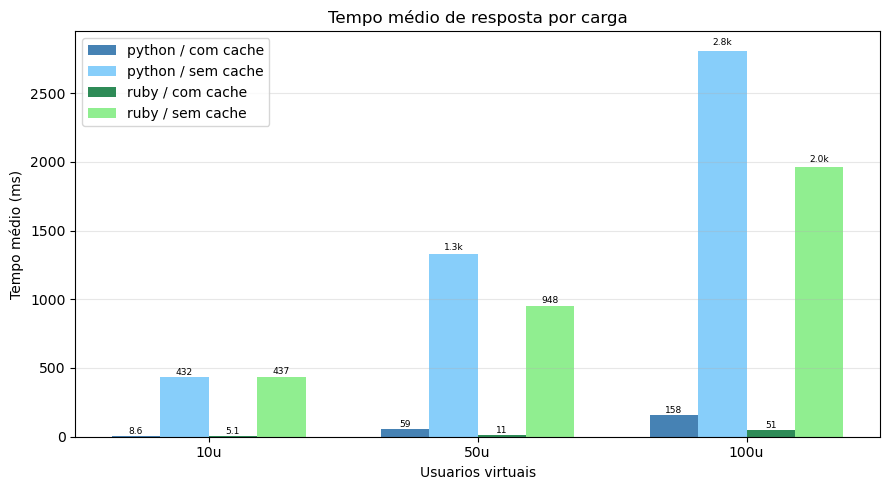

  salvo: c:\Users\kaike\Desktop\nabor\linkextractor-loadtest\results\charts\tempo_resposta_por_carga.png


In [51]:
bar_by_users(resumo, "mean_ms", "Tempo médio (ms)",
              "Tempo médio de resposta por carga",
              "tempo_resposta_por_carga.png")

### 4.2. Mediana (p50)

Metade das requisicoes ficou abaixo deste valor.
Menos sensivel a extremos que a media - se mediana e media divergem muito, ha cauda longa de latencia.

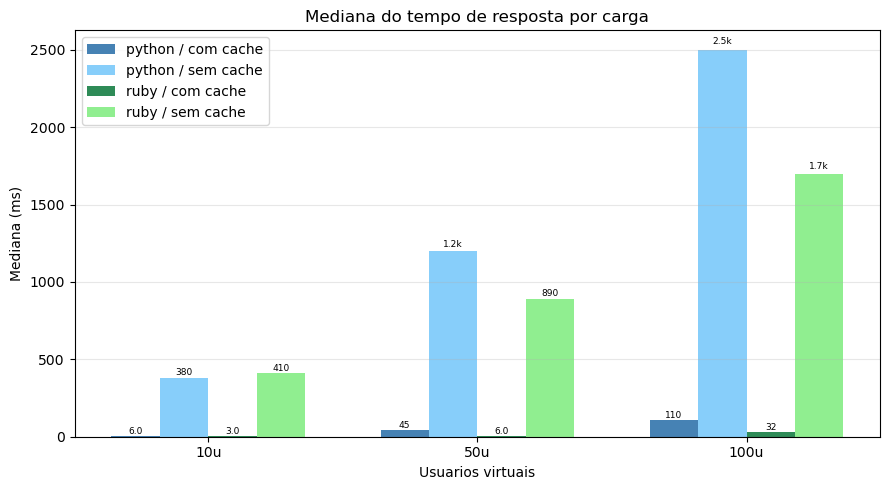

  salvo: c:\Users\kaike\Desktop\nabor\linkextractor-loadtest\results\charts\mediana_por_carga.png


In [52]:
bar_by_users(resumo, "median_ms", "Mediana (ms)",
              "Mediana do tempo de resposta por carga",
              "mediana_por_carga.png")

### 4.3. Percentil 95 (p95)

95% das requisicoes foram atendidas em ate este tempo.
Representa a experiencia do usuario quase mais lento e o limiar mais comum em SLAs de desempenho.

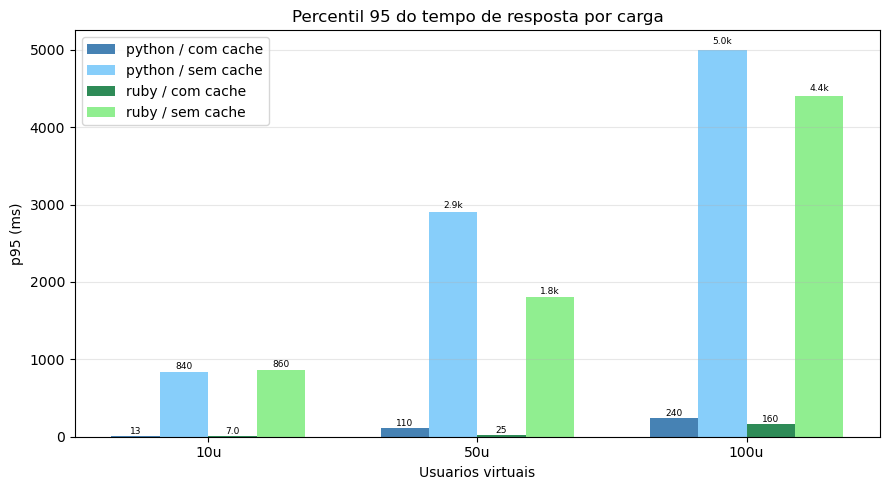

  salvo: c:\Users\kaike\Desktop\nabor\linkextractor-loadtest\results\charts\p95_por_carga.png


In [53]:
bar_by_users(resumo, "p95_ms", "p95 (ms)",
              "Percentil 95 do tempo de resposta por carga",
              "p95_por_carga.png")

### 4.4. Percentil 99 (p99)

Cauda extrema da distribuicao: 99% das requisicoes ficaram abaixo deste valor.
Se p99 cresce muito mais rapido que p95, o sistema tem picos de latencia esporadicos
que afetam poucos clientes, mas podem ser criticos em producao.

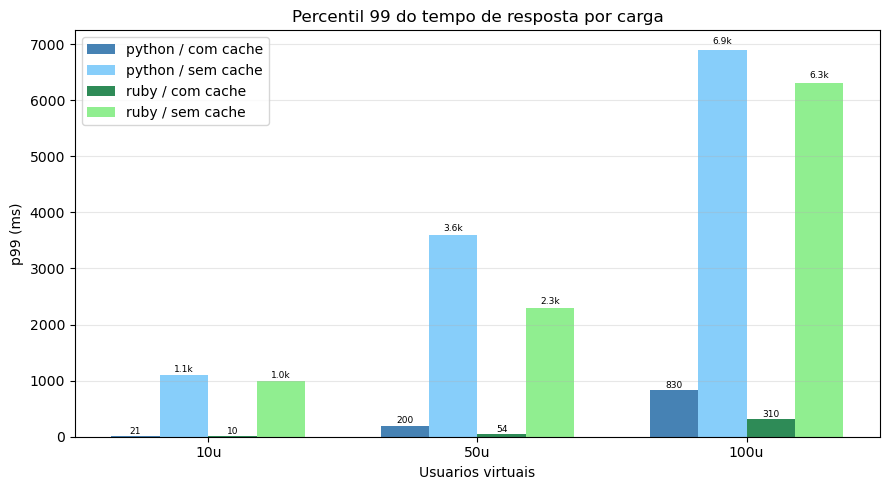

  salvo: c:\Users\kaike\Desktop\nabor\linkextractor-loadtest\results\charts\p99_por_carga.png


In [54]:
bar_by_users(resumo, "p99_ms", "p99 (ms)",
              "Percentil 99 do tempo de resposta por carga",
              "p99_por_carga.png")

### 4.5. Throughput (RPS)

Requisicoes atendidas por segundo em cada cenario.
Se o valor achata ou cai com o aumento de usuarios, o servico atingiu saturacao.

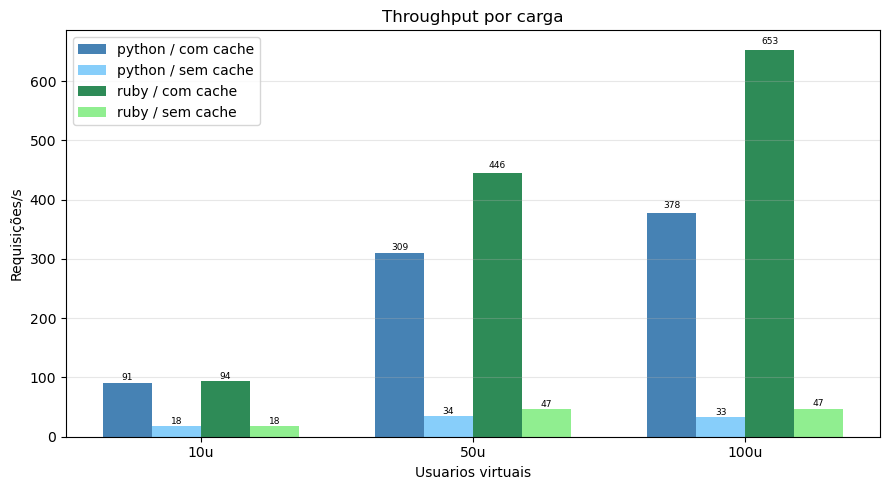

  salvo: c:\Users\kaike\Desktop\nabor\linkextractor-loadtest\results\charts\throughput_por_carga.png


In [55]:
bar_by_users(resumo, "rps", "Requisições/s",
              "Throughput por carga",
              "throughput_por_carga.png")

### 4.6. Falhas absolutas por cenario

Total de requisicoes com resposta HTTP nao-200 em cada cenario.
Falhas concentradas nos cenarios sem cache ou com alta carga indicam que o servico
comeca a rejeitar ou timeout requisicoes nesses limites.

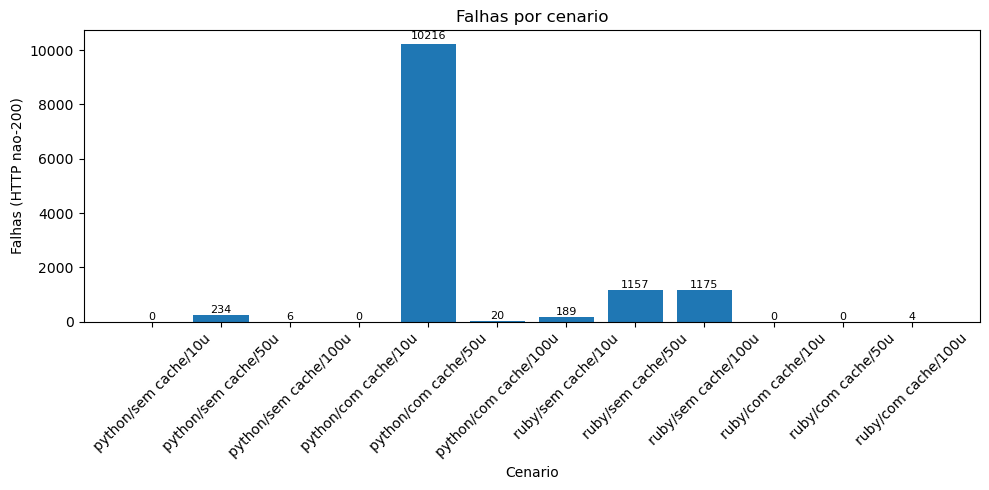

  salvo: c:\Users\kaike\Desktop\nabor\linkextractor-loadtest\results\charts\falhas_por_cenario.png


In [56]:
df_fail = resumo.copy()
df_fail["cache_pt"] = df_fail["cache"].map({"warm": "com cache", "cold": "sem cache"})
df_fail["scenario"] = df_fail["version"] + "/" + df_fail["cache_pt"] + "/" + df_fail["users"].astype(str) + "u"
df_fail = df_fail.sort_values(["version", "cache", "users"])

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(df_fail["scenario"], df_fail["failures"])
for bar, val in zip(bars, df_fail["failures"]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() * 1.01,
            str(int(val)),
            ha="center", va="bottom", fontsize=8)
ax.set_xlabel("Cenario")
ax.set_ylabel("Falhas (HTTP nao-200)")
ax.set_title("Falhas por cenario")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
out = CHARTS / "falhas_por_cenario.png"
fig.savefig(out, dpi=120)
plt.show()
print(f"  salvo: {out}")

### 4.7. Com cache vs Sem cache - comparacao direta

Barras agrupadas lado a lado para cada combinacao versao + carga.
Azul = com cache, laranja = sem cache.
Tres subgraficos (tempo medio, mediana e p95) permitem comparar o ganho do cache
em diferentes metricas e niveis de carga simultaneamente.

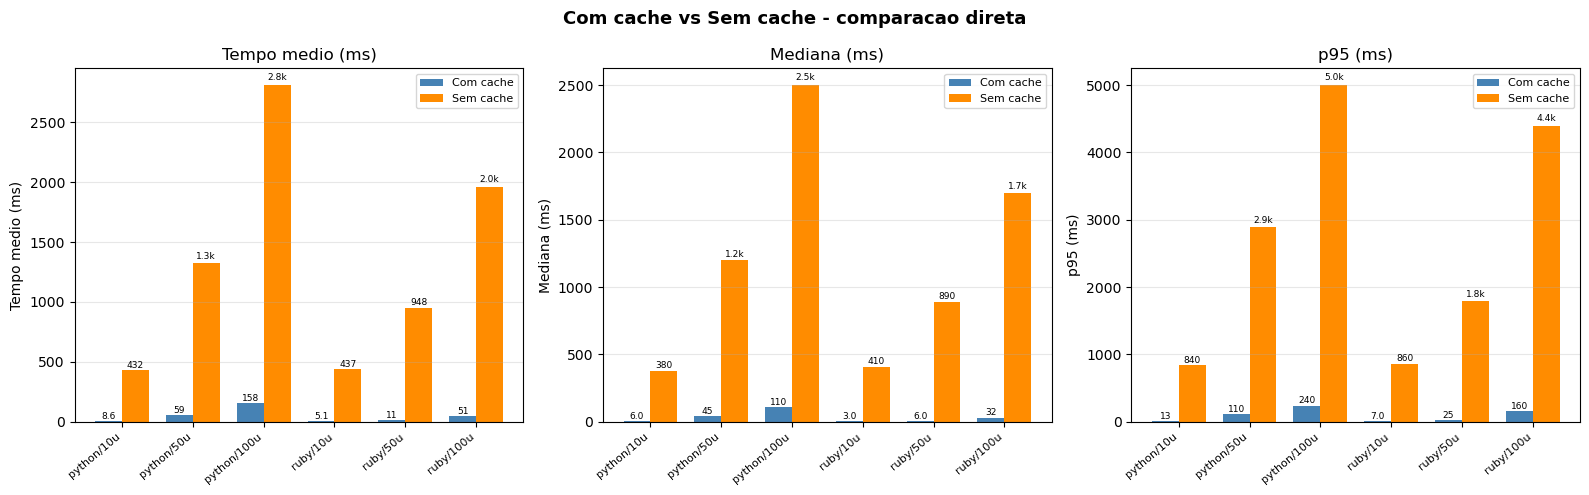

  salvo: c:\Users\kaike\Desktop\nabor\linkextractor-loadtest\results\charts\cache_vs_nocache_barras.png


In [57]:
versions  = resumo["version"].unique()
user_list = sorted(resumo["users"].unique())

groups = [f"{v}/{u}u" for v in versions for u in user_list]

def _vals(cache_val, metric):
    return [
        resumo.loc[(resumo["version"] == v) &
                   (resumo["cache"] == cache_val) &
                   (resumo["users"] == u), metric].values[0]
        for v in versions for u in user_list
    ]

metrics = [
    ("mean_ms",   "Tempo medio (ms)"),
    ("median_ms", "Mediana (ms)"),
    ("p95_ms",    "p95 (ms)"),
]

x = np.arange(len(groups))
width = 0.38

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (metric, ylabel) in zip(axes, metrics):
    warm_vals = _vals("warm", metric)
    cold_vals = _vals("cold", metric)
    bars_w = ax.bar(x - width/2, warm_vals, width, label="Com cache", color="steelblue")
    bars_c = ax.bar(x + width/2, cold_vals, width, label="Sem cache", color="darkorange")
    for bars, vals in [(bars_w, warm_vals), (bars_c, cold_vals)]:
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() * 1.01,
                    _fmt(val),
                    ha="center", va="bottom", fontsize=6.5)
    ax.set_xticks(x)
    ax.set_xticklabels(groups, rotation=40, ha="right", fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle("Com cache vs Sem cache - comparacao direta", fontsize=13, fontweight="bold")
fig.tight_layout()
out = CHARTS / "cache_vs_nocache_barras.png"
fig.savefig(out, dpi=120)
plt.show()
print(f"  salvo: {out}")

### 4.8. Speedup do cache

Razao entre o tempo medio sem cache e com cache (`mean_cold / mean_warm`).
Indica quantas vezes mais rapido o sistema fica com o cache ativo.
Valores proximos de 1 = cache tem pouco efeito; valores altos = ganho expressivo.

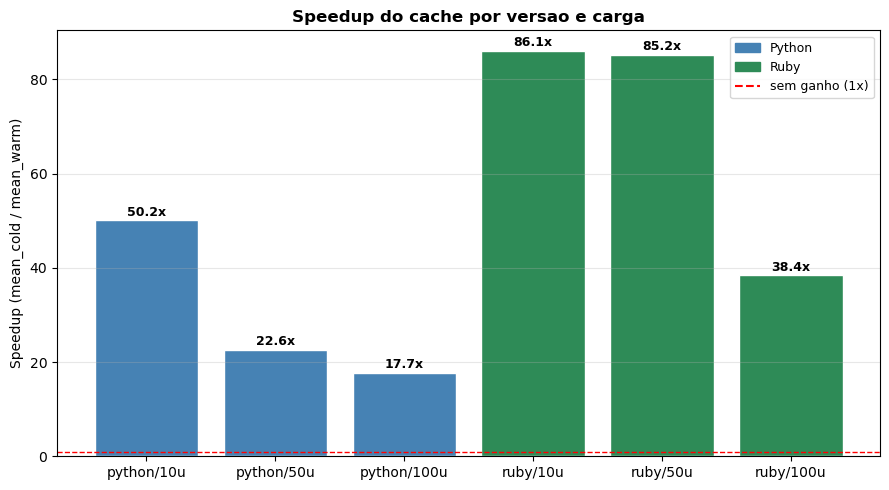

  salvo: c:\Users\kaike\Desktop\nabor\linkextractor-loadtest\results\charts\speedup_cache.png


In [58]:
warm_df = resumo[resumo["cache"] == "warm"].set_index(["version", "users"])
cold_df = resumo[resumo["cache"] == "cold"].set_index(["version", "users"])

speedup_rows = []
for (v, u) in warm_df.index:
    if (v, u) in cold_df.index:
        ratio = cold_df.loc[(v, u), "mean_ms"] / warm_df.loc[(v, u), "mean_ms"]
        speedup_rows.append({"label": f"{v}/{u}u", "speedup": ratio, "version": v, "users": u})

spdf = pd.DataFrame(speedup_rows).sort_values(["version", "users"])
colors = ["steelblue" if v == "python" else "seagreen" for v in spdf["version"]]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(spdf["label"], spdf["speedup"], color=colors, edgecolor="white")
ax.axhline(1, color="red", linestyle="--", linewidth=1)
for bar, val in zip(bars, spdf["speedup"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.1f}x", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_ylabel("Speedup (mean_cold / mean_warm)")
ax.set_title("Speedup do cache por versao e carga", fontweight="bold")
ax.grid(axis="y", alpha=0.3)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="steelblue", label="Python"),
    Patch(color="seagreen",  label="Ruby"),
    plt.Line2D([0],[0], color="red", linestyle="--", label="sem ganho (1x)"),
], fontsize=9)
fig.tight_layout()
out = CHARTS / "speedup_cache.png"
fig.savefig(out, dpi=120)
plt.show()
print(f"  salvo: {out}")

### 4.9. Taxa de erros (%) por cenario

Percentual de requisicoes que falharam (`falhas / total x 100`).
Diferente do total absoluto, permite comparar cenarios com volumes distintos de forma justa:
um cenario com 100 usuarios dispara mais requisicoes e teria mais falhas absolutas
mesmo com a mesma taxa de erro.

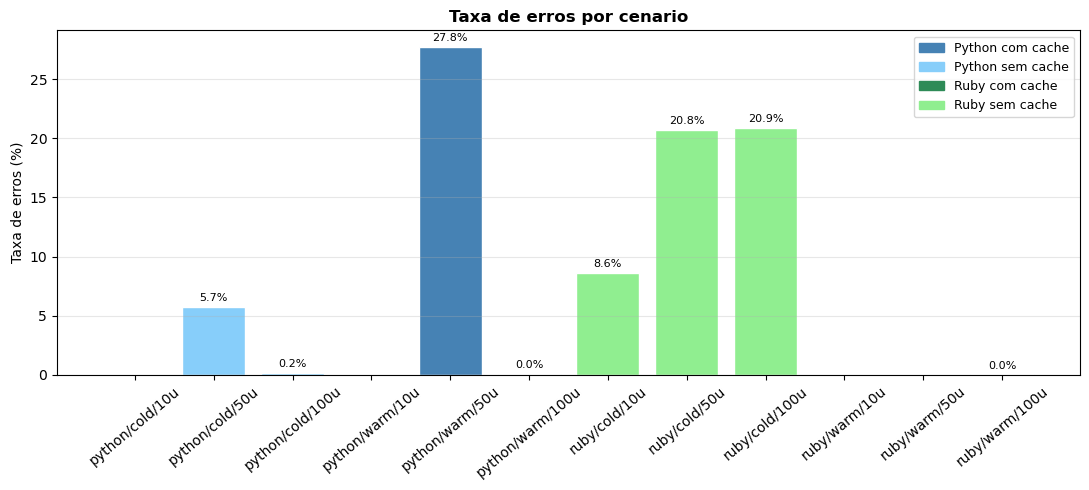

  salvo: c:\Users\kaike\Desktop\nabor\linkextractor-loadtest\results\charts\taxa_erros_pct.png


In [59]:
df_err = resumo.copy()
df_err["error_pct"] = (df_err["failures"] / df_err["requests"].replace(0, float("nan"))) * 100
df_err["scenario"] = df_err["version"] + "/" + df_err["cache"] + "/" + df_err["users"].astype(str) + "u"
df_err = df_err.sort_values(["version", "cache", "users"])

palette = {("python","warm"): "steelblue", ("python","cold"): "lightskyblue",
           ("ruby",  "warm"): "seagreen",  ("ruby",  "cold"): "lightgreen"}
bar_colors = [palette[(r.version, r.cache)] for r in df_err.itertuples()]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(df_err["scenario"], df_err["error_pct"], color=bar_colors, edgecolor="white")
for bar, val in zip(bars, df_err["error_pct"]):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{val:.1f}%", ha="center", va="bottom", fontsize=8)
ax.set_ylabel("Taxa de erros (%)")
ax.set_title("Taxa de erros por cenario", fontweight="bold")
ax.tick_params(axis="x", rotation=40)
ax.grid(axis="y", alpha=0.3)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="steelblue",    label="Python com cache"),
    Patch(color="lightskyblue", label="Python sem cache"),
    Patch(color="seagreen",     label="Ruby com cache"),
    Patch(color="lightgreen",   label="Ruby sem cache"),
], fontsize=9)
fig.tight_layout()
out = CHARTS / "taxa_erros_pct.png"
fig.savefig(out, dpi=120)
plt.show()
print(f"  salvo: {out}")

### 4.10. Heatmap de latencia media

Visao matricial: linhas = combinacao versao/cache, colunas = nivel de carga.
Gradiente de cor (amarelo a vermelho escuro) e valores anotados em cada celula
permitem identificar rapidamente qual combinacao e mais critica e como a latencia
evolui com o aumento da carga.

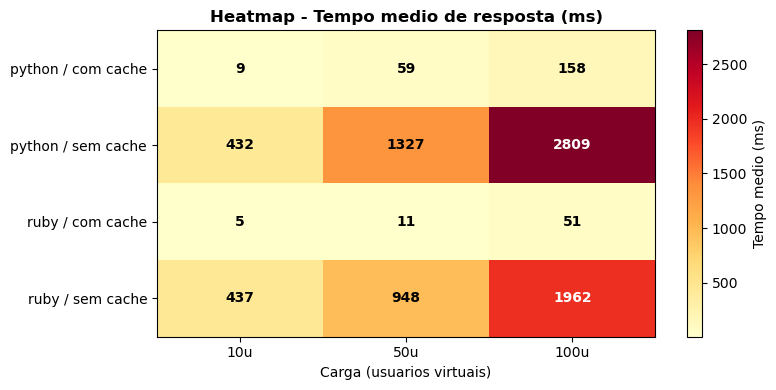

  salvo: c:\Users\kaike\Desktop\nabor\linkextractor-loadtest\results\charts\heatmap_tempo_medio.png


In [60]:
pivot = resumo.pivot_table(
    index=["version", "cache"], columns="users", values="mean_ms"
)
order = [("python","warm"), ("python","cold"), ("ruby","warm"), ("ruby","cold")]
pivot = pivot.reindex([o for o in order if o in pivot.index])
row_labels = [f"{v} / {_CACHE_LABEL[c]}" for v, c in pivot.index]

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd")
plt.colorbar(im, ax=ax, label="Tempo medio (ms)")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"{u}u" for u in pivot.columns])
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels)
ax.set_xlabel("Carga (usuarios virtuais)")
ax.set_title("Heatmap - Tempo medio de resposta (ms)", fontweight="bold")
for i in range(pivot.values.shape[0]):
    for j in range(pivot.values.shape[1]):
        val = pivot.values[i, j]
        text_color = "white" if val > pivot.values.max() * 0.6 else "black"
        ax.text(j, i, f"{val:.0f}", ha="center", va="center",
                fontsize=10, color=text_color, fontweight="bold")
fig.tight_layout()
out = CHARTS / "heatmap_tempo_medio.png"
fig.savefig(out, dpi=120)
plt.show()
print(f"  salvo: {out}")

## 5. Observacoes finais

Use esta secao para registrar as conclusoes da analise.

**Desempenho geral (4.1 a 4.4)**
- Qual versao (Python ou Ruby) apresentou menor latencia media e mediana?
- O p99 cresce proporcionalmente ao p95, ou ha cauda longa em algum cenario?

**Efeito do cache (4.7 e 4.8)**
- Em qual versao o cache produziu maior speedup?
- O ganho do cache se mantem nos tres niveis de carga, ou diminui sob alta carga?

**Capacidade e erros (4.5, 4.6 e 4.9)**
- A partir de qual nivel de carga o throughput satura?
- Qual combinacao versao/cache concentra a maior taxa de erros?
- Ha cenarios onde erros surgem mesmo com cache ativo?

**Visao geral (4.10)**
- O heatmap confirma as conclusoes acima? Ha alguma celula surpreendente?
